# Practical 8: Age Equation at Roosevelt Island, Antarctica

Anna Chen (yc4406)

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def age(p = 3, a_mperyear = 0.1): # 
    # time domain
    dt_years = 10 # time step in years
    seconds_per_year = 365*24*60*60 # approximate number of seconds in year
    dt = dt_years*seconds_per_year # time step in seconds
    time_total_years = 4e5 # total length of the simulation in years
    T = time_total_years*seconds_per_year; # total length of the simulation in seconds
    time = np.linspace(0,T,round(T/dt)) # the time grid, units [years]

    # space domain
    grid_spacing = 10 # grid spacing, units [m]
    ice_thickness = 753 # The max depth of the Roosevelt Age depth profile
    depth = np.linspace(0,ice_thickness,round(ice_thickness/grid_spacing)) # spatial grid, units [m]

    # vertical velocity
    accumulation_rate = a_mperyear/seconds_per_year
    vertical_velocity = -accumulation_rate*(1-(p+2)/(p+1)*(depth/ice_thickness) + 1/(1+p) *(depth/ice_thickness)**(p+2))

    # initial condition 
    Age = np.zeros((time.size,depth.size)) 

    # main loop
    for timestep in np.arange(1,time.size):
        Age[timestep,1:] = Age[timestep-1,1:] + dt * \
        ((vertical_velocity[1:] + vertical_velocity[:-1])/2 * \
        (Age[timestep-1,1:]-Age[timestep-1,:-1])/grid_spacing + 1 ) 

    # return values
    Age_years = Age/seconds_per_year 

    return Age_years, time, depth

# run the model
Age, time, depth = age() 

In [53]:
data = np.loadtxt('RICE17_Interpolated_Ages_20180923.txt', 
skiprows = 29,
encoding = 'latin-1')
depth_measured = data[:,0]
age_measured = data[:,1]

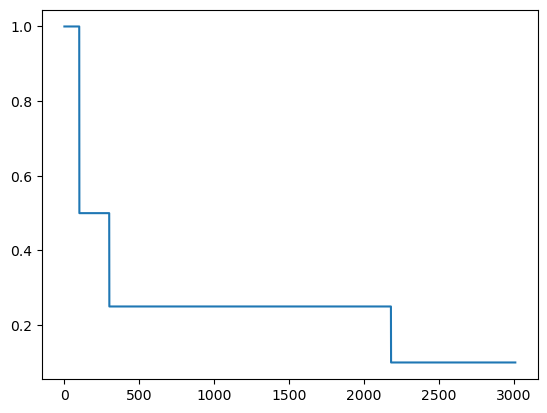

In [54]:
data.shape
depth_space = depth_measured[1:] - depth_measured[:-1]
plt.plot(depth_space)

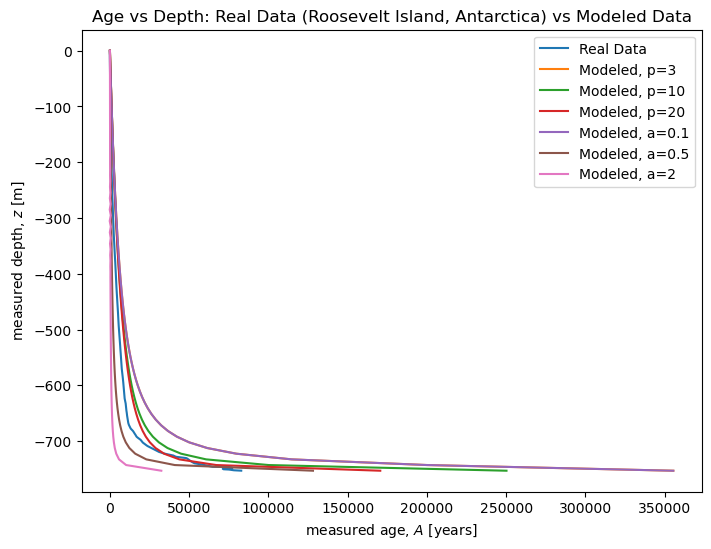

In [55]:
# Manually play around with parameters of the age func

Age0 = age(p=3)[0]
Age1 = age(p=10)[0]
Age2 = age(p=20)[0]

Age3 = age(a_mperyear = 0.1)[0]
Age4 = age(a_mperyear = 0.5)[0]
Age5 = age(a_mperyear = 2)[0]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.plot(age_measured, -depth_measured, label='Real Data')
ax.plot(Age0[-1, :], -depth, label='Modeled, p=3')
ax.plot(Age1[-1, :], -depth, label='Modeled, p=10')
ax.plot(Age2[-1, :], -depth, label='Modeled, p=20')
ax.plot(Age3[-1, :], -depth, label='Modeled, a=0.1')
ax.plot(Age4[-1, :], -depth, label='Modeled, a=0.5')
ax.plot(Age5[-1, :], -depth, label='Modeled, a=2')

ax.set_xlabel('measured age, $A$ [years]')
ax.set_ylabel('measured depth, $z$ [m]')
ax.set_title('Age vs Depth: Real Data (Roosevelt Island, Antarctica) vs Modeled Data')
plt.legend()
plt.show()

In [69]:
from scipy import optimize
from scipy.optimize import minimize

In [ ]:


def optimize_age(guess):
    """
    Parameters:
    
    guess: np.array (1,2)
        guess[0] is p for age function
        guess[1] is a_mperyear for age function
    """
    age_modeled, time_modeled, depth_modeled = age(p=guess[0], a_mperyear=guess[1])
    age_modeled = age_modeled[-1, :]

    # Interpolate the modeled data onto the measured grid
    age_interpolated = np.interp(depth_measured, depth_modeled, age_modeled)

    # Find the RMS of interpolated - measured age on the same depth grid
    diff = age_interpolated - age_measured
    find_rms = lambda x: np.sqrt(np.nanmean(x**2))
    print(f"RMS = {find_rms(diff)}")

    # Minimize RMS
    scipy.optimize.minimize(find_rms, )


In [67]:
optimize_age([3, 0.1])

Difference = [           nan 7.09110656e+01 7.88221311e+01 ... 2.70211521e+05
 2.71080607e+05            nan]
RMS = 46415.728029995116


In [71]:
minimize?

Signature:
minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
    options=None,
)
Docstring:
Minimization of scalar function of one or more variables.

Parameters
----------
fun : callable
    The objective function to be minimized.

        ``fun(x, *args) -> float``

    where ``x`` is a 1-D array with shape (n,) and ``args``
    is a tuple of the fixed parameters needed to completely
    specify the function.
x0 : ndarray, shape (n,)
    Initial guess. Array of real elements of size (n,),
    where ``n`` is the number of independent variables.
args : tuple, optional
    Extra arguments passed to the objective function and its
    derivatives (`fun`, `jac` and `hess` functions).
method : str or callable, optional
    Type of solver.  Should be one of

        - 'Nelder-Mead' :ref:`(see here) <optimize.minimize-neldermead>`
        - 'Powell'      :ref:`(see here) <